<a href="https://colab.research.google.com/github/ga426553-sudo/Classification-of-Breast-Cancer-Subtypes-machine-learning---CuMiDa-22820/blob/main/No_3_KNN_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tercer código - Cáncer de Mama 🌸

**KNN y Evaluation**

In [ ]:
# ============================================
# CÓDIGO 3: KNN Y EVALUACIÓN
# ============================================

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import pickle
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("🔬 CÓDIGO 3: EVALUACIÓN DE KNN")
print("="*60)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔬 CÓDIGO 3: EVALUACIÓN DE KNN


In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold

###Cargar datos 🌺

In [ ]:
# 1. CARGAR DATOS
# ================
print(f"\n📂 Cargando datos del Código 2...")

with open('/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/subsets.pkl', 'rb') as f:
    subsets = pickle.load(f)

y_train = np.load('/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/y_train_final.npy')
y_test = np.load('/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/y_test_final.npy')

print(f"✅ Datos cargados:")
print(f"   Subconjuntos: {list(subsets.keys())}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test: {y_test.shape}")


📂 Cargando datos del Código 2...
✅ Datos cargados:
   Subconjuntos: ['EO', 'BBA', 'CSA', 'RDA', 'GA']
   y_train: (206,)
   y_test: (28,)


###Configuración del KNN 🌺

In [ ]:
# 2. CONFIGURAR KNN
# ==================
knn_params = {
    'n_neighbors': 5,
    'weights': 'uniform',
    'algorithm': 'auto',
    'leaf_size': 30,
    'p': 2,
    'metric': 'minkowski'
}

knn_model = KNeighborsClassifier(**knn_params)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

###Evaluar cada subconjunto 🌺

In [ ]:
# 3. EVALUAR CADA SUBCONJUNTO
# ============================
results = {}

for name in subsets.keys():
    print(f"\n{'─'*40}")
    print(f"🔍 Subconjunto: {name} - Genes: {subsets[name]}")

    X_train_subset = np.load(f'/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/train_{name}.npy')
    X_test_subset = np.load(f'/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/test_{name}.npy')

    # Validación cruzada
    cv_acc = cross_val_score(knn_model, X_train_subset, y_train, cv=cv, scoring='accuracy')
    cv_f1 = cross_val_score(knn_model, X_train_subset, y_train, cv=cv, scoring='f1')
    cv_auc = cross_val_score(knn_model, X_train_subset, y_train, cv=cv, scoring='roc_auc')

    # Evaluación en test
    knn_model.fit(X_train_subset, y_train)
    y_pred = knn_model.predict(X_test_subset)
    y_proba = knn_model.predict_proba(X_test_subset)[:, 1]

    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'cv_accuracy': f"{cv_acc.mean():.4f} ± {cv_acc.std():.4f}",
        'test_accuracy': test_acc,
        'test_f1': test_f1,
        'test_auc': test_auc,
        'genes': subsets[name]
    }

    print(f"   CV Accuracy: {results[name]['cv_accuracy']}")
    print(f"   Test Accuracy: {test_acc:.4f}")
    print(f"   Test F1: {test_f1:.4f}")
    print(f"   Test AUC: {test_auc:.4f}")


────────────────────────────────────────
🔍 Subconjunto: EO - Genes: ['NM_138957', 'NM_152426', 'NM_001008493']
   CV Accuracy: 0.9171 ± 0.0441
   Test Accuracy: 0.9286
   Test F1: 0.9600
   Test AUC: 1.0000

────────────────────────────────────────
🔍 Subconjunto: BBA - Genes: ['NM_152426', 'NM_138957']
   CV Accuracy: 0.9226 ± 0.0612
   Test Accuracy: 0.9286
   Test F1: 0.9615
   Test AUC: 0.9135

────────────────────────────────────────
🔍 Subconjunto: CSA - Genes: ['BC016934', 'NM_006579']
   CV Accuracy: 0.9171 ± 0.0446
   Test Accuracy: 0.7857
   Test F1: 0.8750
   Test AUC: 0.8750

────────────────────────────────────────
🔍 Subconjunto: RDA - Genes: ['BC016934']
   CV Accuracy: 0.7707 ± 0.0899
   Test Accuracy: 0.5714
   Test F1: 0.7143
   Test AUC: 0.4808

────────────────────────────────────────
🔍 Subconjunto: GA - Genes: ['NM_152426']
   CV Accuracy: 0.7824 ± 0.0929
   Test Accuracy: 0.7143
   Test F1: 0.8261
   Test AUC: 0.8077


###Mostrar resumen de los resultados 🌺

In [ ]:

# 4. MOSTRAR RESULTADOS
# ======================
print(f"\n{'='*60}")
print("📊 RESULTADOS FINALES")
print('='*60)

for name, r in results.items():
    print(f"\n{name}:")
    print(f"   Genes: {r['genes']}")
    print(f"   CV Accuracy: {r['cv_accuracy']}")
    print(f"   Test Accuracy: {r['test_accuracy']:.4f}")
    print(f"   Test F1: {r['test_f1']:.4f}")
    print(f"   Test AUC: {r['test_auc']:.4f}")


📊 RESULTADOS FINALES

EO:
   Genes: ['NM_138957', 'NM_152426', 'NM_001008493']
   CV Accuracy: 0.9171 ± 0.0441
   Test Accuracy: 0.9286
   Test F1: 0.9600
   Test AUC: 1.0000

BBA:
   Genes: ['NM_152426', 'NM_138957']
   CV Accuracy: 0.9226 ± 0.0612
   Test Accuracy: 0.9286
   Test F1: 0.9615
   Test AUC: 0.9135

CSA:
   Genes: ['BC016934', 'NM_006579']
   CV Accuracy: 0.9171 ± 0.0446
   Test Accuracy: 0.7857
   Test F1: 0.8750
   Test AUC: 0.8750

RDA:
   Genes: ['BC016934']
   CV Accuracy: 0.7707 ± 0.0899
   Test Accuracy: 0.5714
   Test F1: 0.7143
   Test AUC: 0.4808

GA:
   Genes: ['NM_152426']
   CV Accuracy: 0.7824 ± 0.0929
   Test Accuracy: 0.7143
   Test F1: 0.8261
   Test AUC: 0.8077


In [ ]:
import pandas as pd

print(f"\n{'='*60}")
print("📊 TABLA RESUMEN COMPARATIVA DE RESULTADOS")
print('='*60)

# Crear un DataFrame con los resultados
results_df = pd.DataFrame.from_dict(results, orient='index')

# Seleccionar y reordenar las columnas según lo solicitado por el usuario
# Asegurarse de que 'CV Accuracy' coincida con 'cv_accuracy' en el diccionario 'results'
results_df_display = results_df[['genes', 'test_accuracy', 'test_f1', 'test_auc', 'cv_accuracy']]

# Renombrar columnas para una mejor presentación, si es necesario
results_df_display.columns = ['Genes', 'Test_Accuracy', 'Test_F1', 'Test_AUC', 'CV_Accuracy']
results_df_display.index.name = 'Subset'

# Mostrar la tabla
print(results_df_display.to_string())

print(f"\n{'='*60}")
print("✅ ANÁLISIS DE RESULTADOS COMPLETADO")
print('='*60)



📊 TABLA RESUMEN COMPARATIVA DE RESULTADOS
                                       Genes  Test_Accuracy   Test_F1  Test_AUC      CV_Accuracy
Subset                                                                                          
EO      [NM_138957, NM_152426, NM_001008493]       0.928571  0.960000  1.000000  0.9171 ± 0.0441
BBA                   [NM_152426, NM_138957]       0.928571  0.961538  0.913462  0.9226 ± 0.0612
CSA                    [BC016934, NM_006579]       0.785714  0.875000  0.875000  0.9171 ± 0.0446
RDA                               [BC016934]       0.571429  0.714286  0.480769  0.7707 ± 0.0899
GA                               [NM_152426]       0.714286  0.826087  0.807692  0.7824 ± 0.0929

✅ ANÁLISIS DE RESULTADOS COMPLETADO


### Evaluación con Repeated Stratified K-Fold 🌺

In [ ]:
# ==================================================
# 5. EVALUACIÓN CON REPEATED STRATIFIED K-FOLD
# ==================================================

print("\n" + "="*60)
print("🔄 Realizando evaluación con Repeated Stratified K-Fold")
print("="*60)

# Parámetros iguales a los del artículo
# Re-usamos el modelo knn_model ya configurado

# CV repetida: 10 folds, 5 repeticiones
rkf = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=42)

repeated_cv_results = {}

for name in subsets.keys():
    print(f"\n🔍 Evaluando Subconjunto: {name}")

    X_train_subset = np.load(f'/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/train_{name}.npy')

    acc = cross_val_score(knn_model, X_train_subset, y_train, cv=rkf, scoring='accuracy')
    f1 = cross_val_score(knn_model, X_train_subset, y_train, cv=rkf, scoring='f1')
    auc = cross_val_score(knn_model, X_train_subset, y_train, cv=rkf, scoring='roc_auc')

    repeated_cv_results[name] = {
        'Acc_mean': acc.mean(),
        'Acc_std': acc.std(),
        'F1_mean': f1.mean(),
        'F1_std': f1.std(),
        'AUC_mean': auc.mean(),
        'AUC_std': auc.std()
    }

    print(f"   Accuracy = {acc.mean():.4f} ± {acc.std():.4f}")
    print(f"   F1-Score = {f1.mean():.4f} ± {f1.std():.4f}")
    print(f"   AUC      = {auc.mean():.4f} ± {auc.std():.4f}")

print("\n" + "="*60)
print("✅ Evaluación con Repeated Stratified K-Fold COMPLETADA")
print("="*60)


🔄 Realizando evaluación con Repeated Stratified K-Fold

🔍 Evaluando Subconjunto: EO
   Accuracy = 0.9173 ± 0.0485
   F1-Score = 0.9068 ± 0.0585
   AUC      = 0.9811 ± 0.0273

🔍 Evaluando Subconjunto: BBA
   Accuracy = 0.9206 ± 0.0576
   F1-Score = 0.9117 ± 0.0688
   AUC      = 0.9505 ± 0.0460

🔍 Evaluando Subconjunto: CSA
   Accuracy = 0.9127 ± 0.0452
   F1-Score = 0.9058 ± 0.0511
   AUC      = 0.9588 ± 0.0371

🔍 Evaluando Subconjunto: RDA
   Accuracy = 0.7823 ± 0.0828
   F1-Score = 0.7570 ± 0.0973
   AUC      = 0.8524 ± 0.0852

🔍 Evaluando Subconjunto: GA
   Accuracy = 0.7571 ± 0.0931
   F1-Score = 0.7344 ± 0.1130
   AUC      = 0.8046 ± 0.0965

✅ Evaluación con Repeated Stratified K-Fold COMPLETADA


In [ ]:
# Mostrar los resultados en una tabla
repeated_cv_df = pd.DataFrame.from_dict(repeated_cv_results, orient='index')
repeated_cv_df.index.name = 'Subset'

print(f"\n{'='*60}")
print("📊 RESULTADOS DE REPEATED STRATIFIED K-FOLD")
print('='*60)

# Formatear la tabla para mostrar mean ± std
formatted_df = pd.DataFrame({
    'Accuracy': repeated_cv_df.apply(lambda row: f"{row['Acc_mean']:.4f} ± {row['Acc_std']:.4f}", axis=1),
    'F1-Score': repeated_cv_df.apply(lambda row: f"{row['F1_mean']:.4f} ± {row['F1_std']:.4f}", axis=1),
    'AUC': repeated_cv_df.apply(lambda row: f"{row['AUC_mean']:.4f} ± {row['AUC_std']:.4f}", axis=1)
})

print(formatted_df.to_string())



📊 RESULTADOS DE REPEATED STRATIFIED K-FOLD
               Accuracy         F1-Score              AUC
Subset                                                   
EO      0.9173 ± 0.0485  0.9068 ± 0.0585  0.9811 ± 0.0273
BBA     0.9206 ± 0.0576  0.9117 ± 0.0688  0.9505 ± 0.0460
CSA     0.9127 ± 0.0452  0.9058 ± 0.0511  0.9588 ± 0.0371
RDA     0.7823 ± 0.0828  0.7570 ± 0.0973  0.8524 ± 0.0852
GA      0.7571 ± 0.0931  0.7344 ± 0.1130  0.8046 ± 0.0965


### Visualización de la Distribución del Gen 'BC016934' 🌺

✅ feature_names cargado.
✅ Índice para 'BC016934' encontrado: 9931


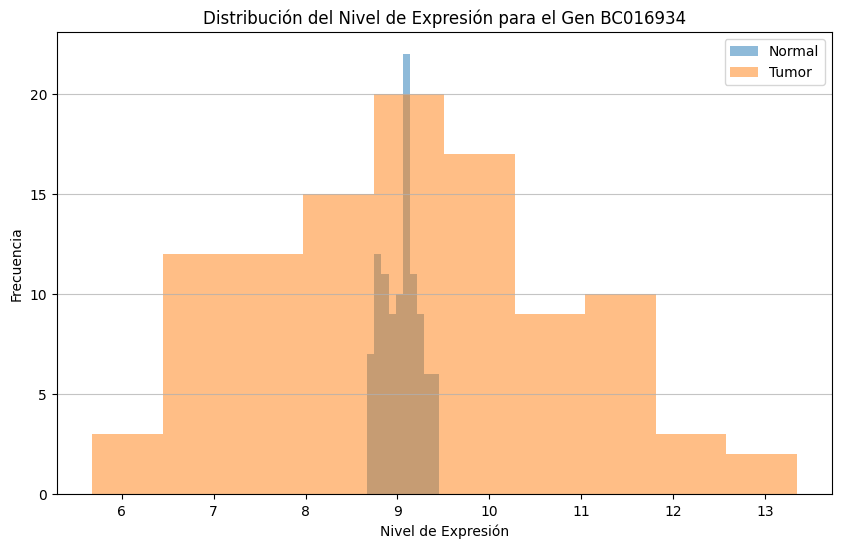

In [ ]:
import pickle
import matplotlib.pyplot as plt

# Asumiendo que 'feature_names.pkl' contiene la lista de todos los nombres de genes
# que corresponden a las columnas de X_train_all. Este archivo debería estar en el
# mismo directorio que tus otros archivos de datos.
# Si este archivo no existe, obtendrás un FileNotFoundError.
try:
    with open('/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/feature_names.pkl', 'rb') as f:
        feature_names = pickle.load(f)
    print("✅ feature_names cargado.")

    if 'BC016934' in feature_names:
        idx = feature_names.index('BC016934')
        print(f"✅ Índice para 'BC016934' encontrado: {idx}")

        # Usar X_train_all (del apartado baseline) como el conjunto de datos de entrenamiento completo
        plt.figure(figsize=(10, 6))
        plt.hist(X_train_all[y_train==0, idx], alpha=0.5, label='Normal')
        plt.hist(X_train_all[y_train==1, idx], alpha=0.5, label='Tumor')
        plt.title(f'Distribución del Nivel de Expresión para el Gen BC016934')
        plt.xlabel('Nivel de Expresión')
        plt.ylabel('Frecuencia')
        plt.legend()
        plt.grid(axis='y', alpha=0.75)
        plt.show()
    else:
        print("Error: El gen 'BC016934' no se encontró en la lista de nombres de características cargada.")
        print("No se pudo generar el gráfico.")

except FileNotFoundError:
    print("Error: 'feature_names.pkl' no encontrado. Por favor, asegúrate de que el archivo existe en la ruta especificada.")
    print("No se pudo generar el gráfico porque falta la lista de nombres de características.")
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")
    print("No se pudo generar el gráfico.")

In [ ]:
# ============================================
# BASELINE: KNN con TODOS los genes
# ============================================

print("\n" + "="*60)
print("📊 BASELINE - KNN con TODOS LOS GENES")
print("="*60)

# Cargar datos completos (después de VarianceThreshold, ANTES de feature selection)
X_train_all = np.load('/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/X_train_balanced.npy')
X_test_all = np.load('/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/X_test_clean.npy')

print(f"Datos baseline: {X_train_all.shape[1]} genes")
print(f"Train: {X_train_all.shape}, Test: {X_test_all.shape}")

# Configurar KNN (mismos parámetros)
knn_baseline = KNeighborsClassifier(
    n_neighbors=5,
    weights='uniform',
    algorithm='auto',
    leaf_size=30,
    p=2,
    metric='minkowski'
)

# Validación cruzada (10-fold)
cv_baseline = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("\n🔄 Ejecutando validación cruzada (10-fold)...")
cv_acc = cross_val_score(knn_baseline, X_train_all, y_train, cv=cv_baseline, scoring='accuracy')
cv_f1 = cross_val_score(knn_baseline, X_train_all, y_train, cv=cv_baseline, scoring='f1')
cv_auc = cross_val_score(knn_baseline, X_train_all, y_train, cv=cv_baseline, scoring='roc_auc')

print(f"\n📊 Resultados Baseline KNN:")
print(f"   CV Accuracy: {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
print(f"   CV F1-Score: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"   CV AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

# Entrenar y evaluar en test
print("\n🔄 Entrenando modelo baseline...")
knn_baseline.fit(X_train_all, y_train)
y_pred = knn_baseline.predict(X_test_all)
y_proba = knn_baseline.predict_proba(X_test_all)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_proba)

print(f"\n📊 Test Baseline KNN:")
print(f"   Test Accuracy: {test_acc:.4f}")
print(f"   Test F1-Score: {test_f1:.4f}")
print(f"   Test AUC: {test_auc:.4f}")

# Guardar baseline results
baseline_results = {
    'cv_accuracy': f"{cv_acc.mean():.4f} ± {cv_acc.std():.4f}",
    'cv_f1': f"{cv_f1.mean():.4f} ± {cv_f1.std():.4f}",
    'cv_auc': f"{cv_auc.mean():.4f} ± {cv_auc.std():.4f}",
    'test_accuracy': test_acc,
    'test_f1': test_f1,
    'test_auc': test_auc
}

with open('/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/baseline_knn.pkl', 'wb') as f:
    pickle.dump(baseline_results, f)

print("\n✅ Baseline KNN guardado en baseline_knn.pkl")


📊 BASELINE - KNN con TODOS LOS GENES
Datos baseline: 31215 genes
Train: (206, 31215), Test: (28, 31215)

🔄 Ejecutando validación cruzada (10-fold)...

📊 Resultados Baseline KNN:
   CV Accuracy: 0.9657 ± 0.0317
   CV F1-Score: 0.9631 ± 0.0347
   CV AUC: 0.9850 ± 0.0229

🔄 Entrenando modelo baseline...

📊 Test Baseline KNN:
   Test Accuracy: 0.9286
   Test F1-Score: 0.9600
   Test AUC: 1.0000

✅ Baseline KNN guardado en baseline_knn.pkl
